In [1]:
!pip install pettingzoo
!pip install 'pettingzoo[all]'
!pip install torch numpy
!pip install supersuit
!pip install multi_agent_ale_py
!pip install autorom[accept-rom-license]
!AutoROM --accept-license

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.5/805.5 kB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 79.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 26.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.5/374.5 kB 35.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 707.8/707.8 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This 

In [2]:
!pip install ffmpeg-python

In [3]:
import torch
import numpy as np
import imageio
import torch.nn as nn
from dataclasses import dataclass
import multi_agent_ale_py
import supersuit as ss
from pettingzoo.atari import boxing_v2
from torch.distributions import Categorical
import wandb

# **Centralised Training-Decentralisd Execution**

In [4]:
MAX_TRAING_STEPS = 10_000
REWARD_DECAY = 0.98
PPO_CLIP1 = 0.2
PPO_CLIP2 = 0.2
GAE_LAMBDA = 0.96
ENTROPY_COEF1 = 0.01
ENTROPY_COEF2 = 0.01
GLOBAL_STEPS = 0
EVALUATION_STEPS = 2048
BATCH_SIZE = 512
EVAL_LOOPS = 3
EPOCHS = 5
ACTOR_LR1 = 5e-3
ACTOR_LR2 = 5e-3
CRITIC_LR = 1e-3
BASE_SEED = 42
TRAINING_CYCLES = 1024
NUM_ENVS = 5
EVAL_CYCLES = 512
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
def create_environment(K_CYCLES, record = False):
    env = boxing_v2.parallel_env(render_mode = False, max_cycles=K_CYCLES)
    env = ss.color_reduction_v0(env, mode='B')
    env = ss.resize_v1(env, 84, 84)
    env = ss.frame_skip_v0(env, 4)
    env = ss.frame_stack_v1(env, 4)

    env = ss.pettingzoo_env_to_vec_env_v1(env)
    parallel_env = ss.concat_vec_envs_v1(
        env, NUM_ENVS, num_cpus=1, base_class='gymnasium'
    )
    return parallel_env

In [6]:
def wandb_runs():
    wandb.login(key="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")
    run = wandb.init(
      project="MAPPO",
      name = f"MAPPO-COLAB"
      )
    return run

In [7]:
env = create_environment(TRAINING_CYCLES, True)
env   # for num_env = 1, it creates 2 copies. don't get confused, its for each agent.

ConcatVecEnv(num_envs=10)

In [8]:
obs, info = env.reset()

In [9]:
obs[0].sum()

np.uint64(445697)

In [10]:
class ConvolutionHead(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

    def forward(self, x):
        x = x / 255.0
        x = self.conv(x)
        return x

In [41]:
class PolicyNetwork(nn.Module):

    def __init__(self, conv_head):
        super().__init__()

        self.conv = conv_head

        self.fc = nn.Sequential(
            nn.Linear(3136, 128),
            nn.ReLU(),
            nn.Linear(128, env.action_space.n)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x

    def choose_actions(self, x, all_actions = None):
        logits = self.forward(x)
        dist = Categorical(logits=logits)
        action = dist.sample() if all_actions is None else all_actions
        log_probs = dist.log_prob(action)
        entropy = dist.entropy()
        return action, log_probs, entropy

In [42]:
class CentralisedCritic(nn.Module):

    def __init__(self, conv_head):
        super().__init__()

        self.conv = conv_head

        self.fc = nn.Sequential(
            nn.Linear(3136, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x

In [43]:
convolution_head = ConvolutionHead()
actornetwork1    = PolicyNetwork(convolution_head).to(device)
actornetwork2    = PolicyNetwork(convolution_head).to(device)
criticnetwork1   = CentralisedCritic(convolution_head).to(device)
criticnetwork2   = CentralisedCritic(convolution_head).to(device)

In [44]:
print(f"==== << {device.upper()} IS BEING USED >> ====")

==== << CUDA IS BEING USED >> ====


In [45]:
import os

def evaluation_loop(actornet_1, actornet_2, record=False, record_episode=1):
    eval_env = boxing_v2.env(render_mode="rgb_array" if record else None, max_cycles=EVAL_CYCLES)
    eval_env = ss.color_reduction_v0(eval_env, mode="B")
    eval_env = ss.resize_v1(eval_env, 84, 84)
    eval_env = ss.frame_stack_v1(eval_env, 4)
    eval_agents = eval_env.possible_agents
    actornets = {eval_agents[0]: actornet_1, eval_agents[1]: actornet_2}
    rewards = {agent: [] for agent in eval_agents}

    for ep in range(EVAL_LOOPS):

      eval_env.reset()
      frames = []
      turn = 0
      num_agents = len(eval_agents)

      for agent in eval_env.agent_iter():
          obs, reward, terminated, truncated, _ = eval_env.last()
          done = terminated or truncated

          rewards[agent].append(float(reward))

          if not done:
              tensor_observation = torch.from_numpy(obs).float().to(device).permute(2, 0, 1)
              with torch.no_grad():
                  logits = actornets[agent](tensor_observation.unsqueeze(0))[0]
                  action = logits.argmax(dim=-1).item()

          else:
              action = None
          eval_env.step(action)
          # print(action)
          turn += 1

          # capture only after a full agent cycle to avoid frozen-looking videos
          if record and ep == record_episode and (turn % num_agents == 0):
              frame = eval_env.render()
              if frame is not None:
                  frames.append(frame)

      # save video for the chosen episode
      if record and ep == record_episode and frames:
          print("saveddd")
          imageio.mimsave("eval_episode.gif", frames, fps=30)
          # runs.log({"evaluation": wandb.Video("eval_episode.gif", fps=30, format="gif")})

    reward_agent1 = sum(rewards[eval_agents[0]]) / EVAL_LOOPS
    reward_agent2 = sum(rewards[eval_agents[1]]) / EVAL_LOOPS

    eval_env.close()
    return reward_agent1, reward_agent2

In [60]:
a, b = evaluation_loop(actornetwork1, actornetwork2, record = True)

saveddd


In [50]:
t = torch.rand(1, 8)
t

tensor([[0.5179, 0.7887, 0.8852, 0.5228, 0.2918, 0.7628, 0.5352, 0.7021]])

In [51]:
t.argmax()

tensor(2)

In [52]:
optimizers = torch.optim.Adam(
    [
        {"params": convolution_head.parameters(), "lr": CRITIC_LR} ,
        {"params": actornetwork1.fc.parameters(), "lr": ACTOR_LR1} ,
        {"params": actornetwork2.fc.parameters(), "lr": ACTOR_LR2} ,
        {"params": criticnetwork1.fc.parameters(), "lr": CRITIC_LR},
        {"params": criticnetwork2.fc.parameters(), "lr": CRITIC_LR}
    ]
)

In [53]:
# actornetwork1_optimizer  = torch.optim.Adam(actornetwork1.parameters(), lr=ACTOR_LR1)
# actornetwork2_optimizer  = torch.optim.Adam(actornetwork2.parameters(), lr=ACTOR_LR2)
# criticnetwork1_optimizer = torch.optim.Adam(criticnetwork1.parameters(), lr=CRITIC_LR)
# criticnetwork2_optimizer = torch.optim.Adam(criticnetwork2.parameters(), lr=CRITIC_LR)

In [54]:
runs = wandb_runs()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Critic_loss1,▆▂▅▃▄▆▂▅▁▂█▁▁
Critic_loss2,▅▂▃▃▅▅▃▅▁▂█▁▁
Entropy-Coeff1,█▇▇▆▆▅▅▄▃▃▂▂▁
Entropy-Coeff2,█▇▇▆▆▅▅▄▃▃▂▂▁
Entropy1,▆▁▇██▆▃▄▇▆█▇▇
Entropy2,█▅▇█▆▄▁▅▂▃▆██
GAE-1,▂▇▃▅▆▃▆▁▆▆█▃▇
GAE-2,▆▁█▆▄▄▆▅▆▂▃▄▃
Global-Steps,▁▂▂▃▃▄▅▅▆▆▇▇█
KL_divergence1,▁▄▆▆▅▅▄▃▇▁▅█▇
+8,...


In [55]:
done = torch.tensor([True, False, True])

done.all()

tensor(False)

In [56]:
GLOBAL_STEPS = 0
RUNNING_STEPS = 0
APPROX_MAX_STEPS = 800
REC_VIDEO = 20000
REWARD_ALPHA = 0.00001
CRITIC_LOSS_SCALE = 0.1

In [57]:
all_seeds= []

In [58]:
for running_step in range(MAX_TRAING_STEPS):

    agents_idx = torch.arange(NUM_ENVS * 2).to(device)

    agent_1_idx = agents_idx[::2]
    agent_2_idx = agents_idx[1::2]

    # =================================================================

    all_states       = []
    all_next_states  = []
    all_rewards      = []
    all_dones        = []

    agent1_actions   = []
    agent2_actions   = []

    agent1_log_probs = []
    agent2_log_probs = []

    SEEDS = BASE_SEED + NUM_ENVS + RUNNING_STEPS
    obs, _ = env.reset(seed = SEEDS)

    agents_idx = torch.arange(NUM_ENVS * 2).to(device)

    agent_1_idx = agents_idx[::2]
    agent_2_idx = agents_idx[1::2]

    obs_T = torch.tensor(obs, dtype=torch.float32, device = device).permute(0, 3, 1, 2)

    done_T = torch.tensor([False]*NUM_ENVS*2, dtype=torch.bool, device=device)

    step = 0

    with torch.no_grad():

      while TRAINING_CYCLES >= step and not done_T.all().item():

          obs1_T = obs_T[agent_1_idx, ...]
          obs2_T = obs_T[agent_2_idx, ...]

          action1, log_probs1, entropy1 = actornetwork1.choose_actions(obs1_T)
          action2, log_probs2, entropy2 = actornetwork2.choose_actions(obs2_T)

          combined_action = torch.cat([action1.unsqueeze(-1), action2.unsqueeze(-1)], dim = -1).reshape(-1).cpu().numpy()

          next_obs, rewards, terminated, truncated, _ = env.step(combined_action)

          done = terminated | truncated

          next_obs_T = torch.tensor(next_obs  , dtype=torch.float32, device = device).permute(0, 3, 1, 2)
          reward_T   = torch.tensor(rewards   , dtype=torch.float32, device = device)
          done_T     = torch.tensor(terminated, dtype=torch.bool, device = device)

          prev_frame = obs_T[:, 2, ...]
          curr_frame = obs_T[:, 3, ...]

          # ==== << REWARDS SHAPING >> ====

          frame_reward = (prev_frame - curr_frame).abs().mean()

          reward_T += REWARD_ALPHA * frame_reward

          all_states.append(obs_T[agent_1_idx, ...])
          all_next_states.append(next_obs_T[agent_1_idx, ...])
          all_rewards.append(reward_T)
          all_dones.append(done_T)

          agent1_actions.append(action1)
          agent2_actions.append(action2)

          agent1_log_probs.append(log_probs1)
          agent2_log_probs.append(log_probs2)

          obs_T = next_obs_T

          # ======== << Evaluation >> ========

          if GLOBAL_STEPS % EVALUATION_STEPS == 0:

            rec = True if GLOBAL_STEPS%REC_VIDEO==0 else False
            rewards_agent1, rewards_agent2 = evaluation_loop(actornetwork1, actornetwork2, record=rec, record_episode=0)

            if rec:
              print(f"Video has been saved at: {GLOBAL_STEPS}")

            if runs is not None:
                runs.log({
                    "rewards_agent1": rewards_agent1,
                    "rewards_agent2": rewards_agent2
                },
                GLOBAL_STEPS)

          step += 1
          GLOBAL_STEPS += 1

    all_stacked_states           = torch.stack(all_states).permute(1, 0, 2, 3, 4)
    all_stacked_next_states      = torch.stack(all_next_states).permute(1, 0, 2, 3, 4)
    all_stacked_rewards          = torch.stack(all_rewards).permute(1, 0)
    all_stacked_dones            = torch.stack(all_dones).permute(1, 0)
    all_stacked_agent1_actions   = torch.stack(agent1_actions).permute(1, 0)
    all_stacked_agent2_actions   = torch.stack(agent2_actions).permute(1, 0)
    all_stacked_agent1_log_probs = torch.stack(agent1_log_probs).permute(1, 0)
    all_stacked_agent2_log_probs = torch.stack(agent2_log_probs).permute(1, 0)

    # ================= << GAE >> =================

    all_stacked_states = all_stacked_states.reshape(-1, 4, 84, 84)
    all_stacked_next_states = all_stacked_next_states.reshape(-1, 4, 84, 84)

    stacked_agent1_rewards = all_stacked_rewards[agent_1_idx, ...].view(-1)
    stacked_agent2_rewards = all_stacked_rewards[agent_2_idx, ...].view(-1)

    stacked_agent1_dones = all_stacked_dones[agent_1_idx, ...].view(-1)
    stacked_agent2_dones = all_stacked_dones[agent_2_idx, ...].view(-1)

    all_stacked_agent1_actions = all_stacked_agent1_actions.reshape(-1)
    all_stacked_agent2_actions = all_stacked_agent2_actions.reshape(-1)

    all_stacked_agent1_log_probs = all_stacked_agent1_log_probs.reshape(-1)
    all_stacked_agent2_log_probs = all_stacked_agent2_log_probs.reshape(-1)

    with torch.no_grad():

        V_s1 = criticnetwork1(all_stacked_states).squeeze(-1)
        V_s2 = criticnetwork2(all_stacked_states).squeeze(-1)

        V_s1_next = criticnetwork1(all_stacked_next_states).squeeze(-1)
        V_s2_next = criticnetwork2(all_stacked_next_states).squeeze(-1)

    delta1 = stacked_agent1_rewards + (1 - stacked_agent1_dones.int()) * REWARD_DECAY * V_s1_next - V_s1
    delta2 = stacked_agent2_rewards + (1 - stacked_agent2_dones.int()) * REWARD_DECAY * V_s2_next - V_s2

    # ==== << reshaping back to the size of [NUM_ENVS, TIME_STEP] >> ====

    delta1 = delta1.reshape(NUM_ENVS, -1)
    delta2 = delta2.reshape(NUM_ENVS, -1)

    stacked_agent1_dones = stacked_agent1_dones.reshape(NUM_ENVS, -1)
    stacked_agent2_dones = stacked_agent2_dones.reshape(NUM_ENVS, -1)

    stacked_agent1_rewards = stacked_agent1_rewards.reshape(NUM_ENVS, -1)
    stacked_agent2_rewards = stacked_agent2_rewards.reshape(NUM_ENVS, -1)

    GAE_1 = torch.zeros_like(stacked_agent1_rewards)
    GAE_2 = torch.zeros_like(stacked_agent2_rewards)

    GAE1_t = torch.zeros_like(delta1[:, 0])
    GAE2_t = torch.zeros_like(delta2[:, 0])

    for t in reversed(range(stacked_agent1_rewards.size(-1))):

      GAE1_t = delta1[:, t] + (1 - stacked_agent1_dones[:, t].int()) * REWARD_DECAY * GAE_LAMBDA * GAE1_t
      GAE2_t = delta2[:, t] + (1 - stacked_agent2_dones[:, t].int()) * REWARD_DECAY * GAE_LAMBDA * GAE2_t

      GAE_1[:, t] = GAE1_t
      GAE_2[:, t] = GAE2_t

    GAE_1 = GAE_1.reshape(-1)
    GAE_2 = GAE_2.reshape(-1)

    agent1_returns = GAE_1 + V_s1
    agent2_returns = GAE_2 + V_s2

    GAE_1 = (GAE_1 - GAE_1.mean()) / (GAE_1.std() + 1e-8)
    GAE_2 = (GAE_2 - GAE_2.mean()) / (GAE_2.std() + 1e-8)

    ppo_running_loss1    = 0
    ppo_running_loss2    = 0

    critic_running_loss1 = 0
    critic_running_loss2 = 0

    entropy1             = 0
    entropy2             = 0

    kl_divergence1       = 0
    kl_divergence2       = 0

    running_entropy_1    = 0
    running_entropy_2    = 0

    step                 = 0

    RUNNING_ENTROPY_COEF1 = max(0.0001, ENTROPY_COEF1 - (ENTROPY_COEF1 * RUNNING_STEPS / APPROX_MAX_STEPS))
    RUNNING_ENTROPY_COEF2 = max(0.0001, ENTROPY_COEF2 - (ENTROPY_COEF2 * RUNNING_STEPS / APPROX_MAX_STEPS))

    for epoch in range(EPOCHS):

        RUNNING_STEPS += 1

        rand_idx = torch.randperm(all_stacked_states.shape[0])

        for idx in range(0, len(rand_idx), BATCH_SIZE):

            mb_idx = rand_idx[idx: idx + BATCH_SIZE]

            mb_states = all_stacked_states[mb_idx]
            mb_next_states = all_stacked_next_states[mb_idx]

            mb_agent1_actions = all_stacked_agent1_actions[mb_idx]
            mb_agent2_actions = all_stacked_agent2_actions[mb_idx]

            mb_GAE_1 = GAE_1[mb_idx]
            mb_GAE_2 = GAE_2[mb_idx]

            mb_log_probs_1 = all_stacked_agent1_log_probs[mb_idx]
            mb_log_probs_2 = all_stacked_agent2_log_probs[mb_idx]

            mb_agent1_returns = agent1_returns[mb_idx]
            mb_agent2_returns = agent2_returns[mb_idx]

            # ============= Critics-Update =============

            mb_V1_st = criticnetwork1(mb_states).squeeze(-1)
            mb_V2_st = criticnetwork2(mb_states).squeeze(-1)

            critic_loss1 = torch.nn.functional.mse_loss(mb_V1_st, mb_agent1_returns)
            critic_loss2 = torch.nn.functional.mse_loss(mb_V2_st, mb_agent2_returns)

            critic_loss = (critic_loss1 + critic_loss2) / 2

            # ============= Actor-Update =============

            _, new_log_probs1, entropy1 = actornetwork1.choose_actions(mb_states, mb_agent1_actions)
            _, new_log_probs2, entropy2 = actornetwork2.choose_actions(mb_states, mb_agent2_actions)

            ratio1 = torch.exp(new_log_probs1 - mb_log_probs_1)
            ratio2 = torch.exp(new_log_probs2 - mb_log_probs_2)

            ppo1 = torch.min(ratio1 * mb_GAE_1, torch.clamp(ratio1, 1 - PPO_CLIP1, 1 + PPO_CLIP1)*mb_GAE_1).mean()
            ppo2 = torch.min(ratio2 * mb_GAE_2, torch.clamp(ratio2, 1 - PPO_CLIP2, 1 + PPO_CLIP2)*mb_GAE_2).mean()

            ppo_loss1 = - ppo1 - RUNNING_ENTROPY_COEF1 * entropy1.mean()
            ppo_loss2 = - ppo2 - RUNNING_ENTROPY_COEF2 * entropy2.mean()

            ppo_loss = (ppo_loss1 + ppo_loss2) / 2

            loss = ppo_loss + (CRITIC_LOSS_SCALE*critic_loss)

            optimizers.zero_grad()
            loss.backward()
            optimizers.step()

            kl_divergence1 += (new_log_probs1 - mb_log_probs_1).mean().item()
            kl_divergence2 += (new_log_probs2 - mb_log_probs_2).mean().item()

            ppo_running_loss1 += ppo_loss1.item()
            ppo_running_loss2 += ppo_loss2.item()
            critic_running_loss1 += critic_loss1.item()
            critic_running_loss2 += critic_loss2.item()
            running_entropy_1 += entropy1.mean().item()
            running_entropy_2 += entropy2.mean().item()

            step += 1

        if runs is not None:

            runs.log(
                {
                    "Training-Reward-Agent-1": stacked_agent1_rewards.mean().item(),
                    "Training-Reward-Agent-2": stacked_agent2_rewards.mean().item(),
                    "PPO_loss1": ppo_running_loss1 / step,
                    "PPO_loss2": ppo_running_loss2 / step,
                    "Critic_loss1": critic_running_loss1 / step,
                    "Critic_loss2": critic_running_loss2 / step,
                    "Entropy1": running_entropy_1 / step,
                    "Entropy2": running_entropy_2 / step,
                    "KL_divergence1": kl_divergence1 / step,
                    "KL_divergence2": kl_divergence2 / step,
                    "GAE-1": mb_GAE_1.mean().item(),
                    "GAE-2": mb_GAE_2.mean().item(),
                    "Entropy-Coeff1": RUNNING_ENTROPY_COEF1,
                    "Entropy-Coeff2": RUNNING_ENTROPY_COEF2,
                    "Global-Steps": GLOBAL_STEPS,
                    "Seeds" : SEEDS
                },
                GLOBAL_STEPS
            )

saveddd
Video has been saved at: 0


KeyboardInterrupt: 

In [88]:
entropy1

tensor([2.8882, 2.8882, 2.8882, 2.8882, 2.8882], device='cuda:0')

In [83]:
all_stacked_rewards[2]

tensor([0.0063, 0.0002, 0.0002,  ..., 0.0002, 0.0002, 0.0063], device='cuda:0')

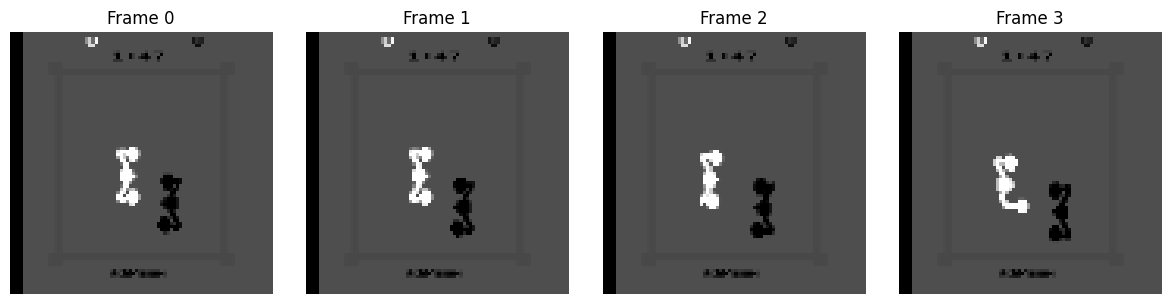

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# obs is your (4, 84, 84) tensor — 4 stacked grayscale frames
obs = all_stacked_states[700].cpu().numpy()  # (4, 84, 84)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(obs[i], cmap='gray')
    axes[i].set_title(f'Frame {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
obs_T.size()

In [ ]:
prev_frame = obs_T[:, 2, ...]
curr_frame = obs_T[:, 3, ...]

In [ ]:
prev_frame.shape

In [ ]:
(prev_frame - curr_frame).abs().mean()